# OULAD Early Prediction Project
**Student Name:** Vukosi Khoza (2605669)

**Objective:** Predict student outcome (Fail/Pass) using only data available up to week 4.

**Brief alignment:** This notebook builds and compares two machine learning pipelines, engineers week-4 features from aggregated OULAD data, avoids training directly on the raw clickstream table, and includes the required feature table and pipeline comparison table from the 2026 individual project brief.


## 1. Imports and Setup

This section imports all required libraries and sets up the environment for the analysis.

In [147]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

## 2. Data Loading

Load all OULAD dataset files and verify that they are correctly imported.

In [148]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path(".")   # current notebook folder

files = {
    "studentInfo": "studentInfo.csv",
    "studentVle": "studentVle.csv",
    "vle": "vle.csv",
    "assessments": "assessments.csv",
    "studentAssessment": "studentAssessment.csv",
    "studentRegistration": "studentRegistration.csv",
    "courses": "courses.csv",
}

for name, file in files.items():
    path = DATA_DIR / file
    print(name, "exists:", path.exists(), "| path:", path)

student_info = pd.read_csv(DATA_DIR / "studentInfo.csv")
student_vle = pd.read_csv(DATA_DIR / "studentVle.csv")
vle = pd.read_csv(DATA_DIR / "vle.csv")
assessments = pd.read_csv(DATA_DIR / "assessments.csv")
student_assessment = pd.read_csv(DATA_DIR / "studentAssessment.csv")
student_registration = pd.read_csv(DATA_DIR / "studentRegistration.csv")
courses = pd.read_csv(DATA_DIR / "courses.csv")

print("Loaded successfully")

studentInfo exists: True | path: studentInfo.csv
studentVle exists: True | path: studentVle.csv
vle exists: True | path: vle.csv
assessments exists: True | path: assessments.csv
studentAssessment exists: True | path: studentAssessment.csv
studentRegistration exists: True | path: studentRegistration.csv
courses exists: True | path: courses.csv
Loaded successfully


## 3. Data Overview

Inspect dataset shapes and basic structure to understand available information.

In [149]:
print("student_info:", student_info.shape)
print("student_vle:", student_vle.shape)
print("vle:", vle.shape)
print("assessments:", assessments.shape)
print("student_assessment:", student_assessment.shape)
print("student_registration:", student_registration.shape)
print("courses:", courses.shape)

student_info: (32593, 12)
student_vle: (10655280, 6)
vle: (6364, 6)
assessments: (206, 6)
student_assessment: (173912, 5)
student_registration: (32593, 5)
courses: (22, 3)


## 4. Target Definition

Define the prediction target:
- Pass / Distinction → 1 (favourable)
- Fail / Withdrawn → 0 (at-risk)

In [150]:
# Create binary target
student_info["target"] = student_info["final_result"].map({
    "Pass": 1,
    "Distinction": 1,
    "Fail": 0,
    "Withdrawn": 0
})

# Check mapping worked
print(student_info[["final_result", "target"]].head())

# Check class distribution
print("\nClass distribution:")
print(student_info["target"].value_counts())

print("\nProportions:")
print(student_info["target"].value_counts(normalize=True))

  final_result  target
0         Pass       1
1         Pass       1
2    Withdrawn       0
3         Pass       1
4         Pass       1

Class distribution:
target
0    17208
1    15385
Name: count, dtype: int64

Proportions:
target
0    0.527966
1    0.472034
Name: proportion, dtype: float64


In [151]:
if "target" not in student_info.columns:
    student_info["target"] = student_info["final_result"].map({
        "Pass": 1,
        "Distinction": 1,
        "Fail": 0,
        "Withdrawn": 0
    })
    print("`target` was missing, so it was recreated from `final_result`.")

print(student_info["target"].isnull().sum())


0


## 5. Week 4 Filtering (Leakage Prevention)

To ensure a fair prediction task, only data available up to the end of week 4 (days 0–27) is used.

This prevents data leakage, where the model would otherwise learn from future information.

In [152]:
# Keep only interactions from days 0-27 (end of week 4)
student_vle_w4 = student_vle[student_vle["date"] <= 27].copy()

print("Original VLE:", student_vle.shape)
print("Week 4 VLE:", student_vle_w4.shape)

print(student_vle_w4.columns)

Original VLE: (10655280, 6)
Week 4 VLE: (2801311, 6)
Index(['code_module', 'code_presentation', 'id_student', 'id_site', 'date',
       'sum_click'],
      dtype='object')


In [153]:
# Merge student assessments with assessment info to get dates
student_assessment_merged = student_assessment.merge(
    assessments,
    on="id_assessment",
    how="left"
)

# Keep only assessments due up to week 4
student_assessment_w4 = student_assessment_merged[
    student_assessment_merged["date"] <= 27
].copy()

print("Original assessments:", student_assessment.shape)
print("Week 4 assessments:", student_assessment_w4.shape)

Original assessments: (173912, 5)
Week 4 assessments: (22043, 10)


In [154]:
# Registration info (we don't filter here, but inspect it)
student_registration.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [155]:
print(student_vle_w4["date"].max())
print(student_assessment_w4["date"].max())

27
25.0


## 6. Feature Engineering

Create meaningful features using only data available up to week 4:
- VLE activity (student engagement)
- Assessment performance (early scores)
- Student demographics

These features will be used to train prediction models.

In [156]:
vle_features = (
    student_vle_w4
    .groupby(["code_module", "code_presentation", "id_student"])
    .agg(
        total_clicks_w4=("sum_click", "sum"),
        avg_clicks_w4=("sum_click", "mean"),
        active_days_w4=("date", "nunique"),
        total_events_w4=("id_site", "count"),
        unique_sites_w4=("id_site", "nunique")
    )
    .reset_index()
)

vle_features.head()

,code_module,code_presentation,id_student,total_clicks_w4,avg_clicks_w4,active_days_w4,total_events_w4,unique_sites_w4
0,AAA,2013J,11391,401,6.683333,8,60,24
1,AAA,2013J,28400,550,3.691275,18,149,30
2,AAA,2013J,30268,281,3.697368,12,76,22
3,AAA,2013J,31604,478,3.514706,21,136,30
4,AAA,2013J,32885,567,3.754967,24,151,34


In [157]:
# Add activity type information to week-4 VLE data
student_vle_w4_activity = student_vle_w4.merge(
    vle[["id_site", "activity_type"]],
    on="id_site",
    how="left"
)

activity_features = (
    student_vle_w4_activity
    .groupby(["code_module", "code_presentation", "id_student", "activity_type"])
    ["sum_click"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

activity_features.head()

activity_type,code_module,code_presentation,id_student,dataplus,dualpane,externalquiz,forumng,glossary,homepage,htmlactivity,...,oucontent,ouelluminate,ouwiki,page,questionnaire,quiz,resource,sharedsubpage,subpage,url
0,AAA,2013J,11391,0,0,0,55,0,42,0,...,273,0,0,0,0,0,9,0,21,1
1,AAA,2013J,28400,0,0,0,204,0,121,0,...,138,0,0,0,0,0,5,0,55,27
2,AAA,2013J,30268,0,0,0,126,0,59,0,...,66,0,0,0,0,0,4,0,22,4
3,AAA,2013J,31604,0,0,0,131,1,94,0,...,175,0,0,0,0,0,10,0,50,17
4,AAA,2013J,32885,0,0,0,138,2,102,0,...,284,0,0,0,0,0,7,0,28,6


In [158]:
assessment_features = (
    student_assessment_w4
    .groupby(["code_module", "code_presentation", "id_student"])
    .agg(
        mean_score_w4=("score", "mean"),
        total_score_w4=("score", "sum"),
        assessments_done_w4=("id_assessment", "count")
    )
    .reset_index()
)

assessment_features.head()

,code_module,code_presentation,id_student,mean_score_w4,total_score_w4,assessments_done_w4
0,AAA,2013J,11391,78.0,78.0,1
1,AAA,2013J,28400,70.0,70.0,1
2,AAA,2013J,31604,72.0,72.0,1
3,AAA,2013J,32885,69.0,69.0,1
4,AAA,2013J,38053,79.0,79.0,1


In [159]:
if "target" not in student_info.columns:
    student_info["target"] = student_info["final_result"].map({
        "Pass": 1,
        "Distinction": 1,
        "Fail": 0,
        "Withdrawn": 0
    })
    print("`target` was missing, so it was recreated from `final_result`.")

demographic_features = student_info[[
    "code_module",
    "code_presentation",
    "id_student",
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "num_of_prev_attempts",
    "studied_credits",
    "disability",
    "target"
]].copy()

demographic_features.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,target
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,1
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,1
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,1
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,1


In [160]:
df = demographic_features.merge(
    vle_features,
    on=["code_module", "code_presentation", "id_student"],
    how="left"
)

df = df.merge(
    activity_features,
    on=["code_module", "code_presentation", "id_student"],
    how="left"
)

df = df.merge(
    assessment_features,
    on=["code_module", "code_presentation", "id_student"],
    how="left"
)

# Fill missing values safely by column type
cat_cols_df = df.select_dtypes(include=["object", "bool"]).columns
num_cols_df = df.select_dtypes(include=["int64", "float64"]).columns

df[cat_cols_df] = df[cat_cols_df].fillna("Missing")
df[num_cols_df] = df[num_cols_df].fillna(0)

df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,page,questionnaire,quiz,resource,sharedsubpage,subpage,url,mean_score_w4,total_score_w4,assessments_done_w4
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,0.0,0.0,0.0,9.0,0.0,21.0,1.0,78.0,78.0,1.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,0.0,0.0,0.0,5.0,0.0,55.0,27.0,70.0,70.0,1.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.0,0.0,0.0,4.0,0.0,22.0,4.0,0.0,0.0,0.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,0.0,0.0,0.0,10.0,0.0,50.0,17.0,72.0,72.0,1.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,0.0,0.0,0.0,7.0,0.0,28.0,6.0,69.0,69.0,1.0


In [161]:
print("Final dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Target distribution:")
print(df["target"].value_counts(normalize=True))

Final dataset shape: (32593, 38)
Missing values: 0
Target distribution:
target
0    0.527966
1    0.472034
Name: proportion, dtype: float64


## 7. Train/Test Split

Separate the engineered dataset into features and target, then split into training and testing sets using stratified sampling to preserve the target class balance.


In [162]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["target", "id_student"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

X_train: (26074, 36)
X_test: (6519, 36)
y_train distribution:
target
0    0.527959
1    0.472041
Name: proportion, dtype: float64
y_test distribution:
target
0    0.527995
1    0.472005
Name: proportion, dtype: float64


## 8. Pipeline 1 – Logistic Regression

This baseline pipeline uses course-covered methods:
- One-hot encoding for categorical features
- Standard scaling for numerical features
- Logistic Regression classifier

In [163]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Identify feature types
categorical_cols = X_train.select_dtypes(include=["object", "bool"]).columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numeric columns:", list(numeric_cols))

Categorical columns: ['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
Numeric columns: ['num_of_prev_attempts', 'studied_credits', 'total_clicks_w4', 'avg_clicks_w4', 'active_days_w4', 'total_events_w4', 'unique_sites_w4', 'dataplus', 'dualpane', 'externalquiz', 'forumng', 'glossary', 'homepage', 'htmlactivity', 'oucollaborate', 'oucontent', 'ouelluminate', 'ouwiki', 'page', 'questionnaire', 'quiz', 'resource', 'sharedsubpage', 'subpage', 'url', 'mean_score_w4', 'total_score_w4', 'assessments_done_w4']


In [164]:
# Preprocessing for Pipeline 1
preprocessor_p1 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

# Pipeline 1: Logistic Regression
pipeline_1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_p1),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# Train model
pipeline_1.fit(X_train, y_train)

print("Pipeline 1 trained successfully")

Pipeline 1 trained successfully


In [165]:
train_score_p1 = pipeline_1.score(X_train, y_train)
test_score_p1 = pipeline_1.score(X_test, y_test)

print("Train accuracy:", train_score_p1)
print("Test accuracy:", test_score_p1)

Train accuracy: 0.7504794047710363
Test accuracy: 0.755483969934039


## 9. Pipeline 1 Evaluation

Evaluate the Logistic Regression pipeline using confusion matrix, classification report, ROC curve, and AUC.

              precision    recall  f1-score   support

           0       0.80      0.72      0.76      3442
           1       0.72      0.80      0.75      3077

    accuracy                           0.76      6519
   macro avg       0.76      0.76      0.76      6519
weighted avg       0.76      0.76      0.76      6519

AUC: 0.8407980750510291


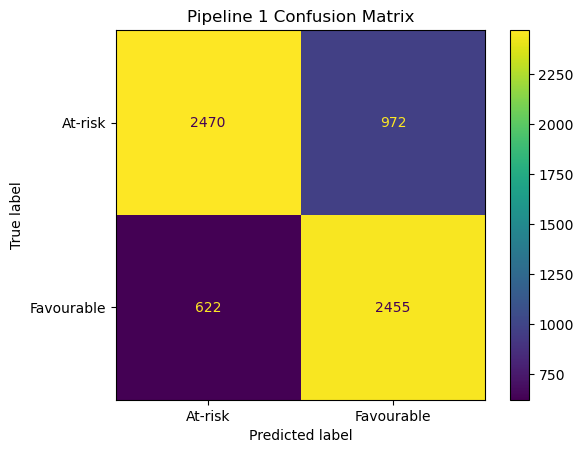

In [166]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred_p1 = pipeline_1.predict(X_test)
y_proba_p1 = pipeline_1.predict_proba(X_test)[:, 1]

# Classification report
print(classification_report(y_test, y_pred_p1))

# AUC
auc_p1 = roc_auc_score(y_test, y_proba_p1)
print("AUC:", auc_p1)

# Confusion matrix
cm_p1 = confusion_matrix(y_test, y_pred_p1)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_p1,
    display_labels=["At-risk", "Favourable"]
)

disp.plot()
plt.title("Pipeline 1 Confusion Matrix")
plt.show()

## 10. Threshold Tuning

Use an illustrative threshold sweep to show the operating-point trade-off for Pipeline 1.

- Class `0` = at-risk
- Class `1` = favourable
- The threshold below is applied to the predicted probability of class `1`

Because this notebook uses a single hold-out split, the `0.60` threshold should be read as an example operating point rather than a final production-tuned threshold.


In [167]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score

required_objects = ["y_test", "y_proba_p1"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    print(
        "Section 10 requires the model outputs from Sections 8 and 9. "
        "Run the notebook through Section 9 first, then rerun this cell. "
        f"Missing: {', '.join(missing_objects)}"
    )
    threshold_results = pd.DataFrame(
        columns=[
            "threshold_for_class_1",
            "at_risk_precision_0",
            "at_risk_recall_0",
            "at_risk_f1_0",
            "favourable_recall_1",
            "balanced_accuracy",
        ]
    )
else:
    thresholds = np.arange(0.10, 0.90, 0.05)
    threshold_results = []

    for t in thresholds:
        y_pred_thresh = (y_proba_p1 >= t).astype(int)
        threshold_results.append(
            {
                "threshold_for_class_1": t,
                "at_risk_precision_0": precision_score(y_test, y_pred_thresh, pos_label=0, zero_division=0),
                "at_risk_recall_0": recall_score(y_test, y_pred_thresh, pos_label=0, zero_division=0),
                "at_risk_f1_0": f1_score(y_test, y_pred_thresh, pos_label=0, zero_division=0),
                "favourable_recall_1": recall_score(y_test, y_pred_thresh, pos_label=1, zero_division=0),
                "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_thresh),
            }
        )

    threshold_results = pd.DataFrame(threshold_results).round(3)

threshold_results


,threshold_for_class_1,at_risk_precision_0,at_risk_recall_0,at_risk_f1_0,favourable_recall_1,balanced_accuracy
0,0.10,0.984,0.365,0.532,0.994,0.679
1,0.15,0.976,0.389,0.556,0.989,0.689
2,0.20,0.966,0.424,0.589,0.983,0.704
3,0.25,0.947,0.469,0.627,0.970,0.720
4,0.30,0.921,0.511,0.658,0.951,0.731
5,0.35,0.892,0.564,0.691,0.924,0.744
6,0.40,0.865,0.621,0.723,0.891,0.756
7,0.45,0.833,0.671,0.744,0.850,0.760
8,0.50,0.799,0.718,0.756,0.798,0.758
9,0.55,0.766,0.770,0.768,0.737,0.754


In [168]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score

threshold = 0.60
required_objects = ["y_test", "y_proba_p1"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    print(
        "Section 10 threshold evaluation requires the Pipeline 1 predictions from Sections 8 and 9. "
        "Run the notebook through Section 9 first, then rerun this cell. "
        f"Missing: {', '.join(missing_objects)}"
    )
else:
    y_pred_tuned = (y_proba_p1 >= threshold).astype(int)
    print(f"Illustrative threshold for class 1 probability: {threshold:.2f}")
    print("A higher threshold predicts class 1 less often, which increases recall for class 0 (at-risk).")
    print()
    print(classification_report(y_test, y_pred_tuned))

    cm_tuned = confusion_matrix(y_test, y_pred_tuned)
    print("Confusion matrix:")
    print(cm_tuned)
    print()
    print("At-risk recall (class 0):", round(recall_score(y_test, y_pred_tuned, pos_label=0), 3))
    print("Favourable recall (class 1):", round(recall_score(y_test, y_pred_tuned, pos_label=1), 3))


Illustrative threshold for class 1 probability: 0.60
A higher threshold predicts class 1 less often, which increases recall for class 0 (at-risk).

              precision    recall  f1-score   support

           0       0.73      0.82      0.77      3442
           1       0.77      0.66      0.71      3077

    accuracy                           0.75      6519
   macro avg       0.75      0.74      0.74      6519
weighted avg       0.75      0.75      0.74      6519

Confusion matrix:
[[2824  618]
 [1037 2040]]

At-risk recall (class 0): 0.82
Favourable recall (class 1): 0.663


## 11. Pipeline 2 – Advanced Model

This pipeline changes the model component by using a Gradient Boosting classifier. This is the self-learned improvement beyond the baseline Logistic Regression pipeline.

In [169]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing for Pipeline 2
# Tree-based boosting does not need scaling.
preprocessor_p2 = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# Pipeline 2: Gradient Boosting
pipeline_2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_p2),
        ("model", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

pipeline_2.fit(X_train, y_train)

print("Pipeline 2 trained successfully")

Pipeline 2 trained successfully


In [171]:
train_score_p2 = pipeline_2.score(X_train, y_train)
test_score_p2 = pipeline_2.score(X_test, y_test)

print("Pipeline 2 train accuracy:", train_score_p2)
print("Pipeline 2 test accuracy:", test_score_p2)

Pipeline 2 train accuracy: 0.7881797959653295
Pipeline 2 test accuracy: 0.7697499616505599


              precision    recall  f1-score   support

           0       0.82      0.73      0.77      3442
           1       0.73      0.82      0.77      3077

    accuracy                           0.77      6519
   macro avg       0.77      0.77      0.77      6519
weighted avg       0.77      0.77      0.77      6519

Pipeline 2 AUC: 0.8492504131324665


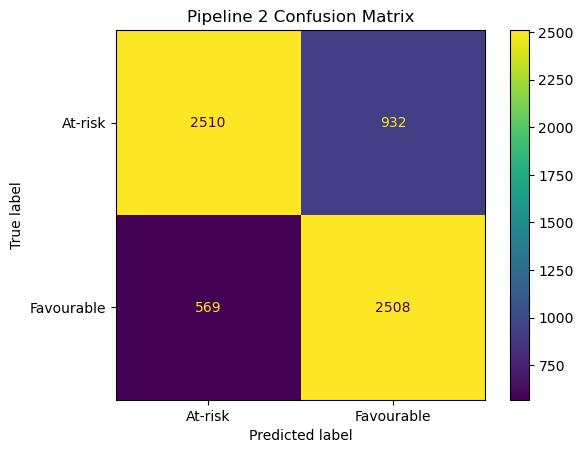

In [170]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_p2 = pipeline_2.predict(X_test)
y_proba_p2 = pipeline_2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_p2))

auc_p2 = roc_auc_score(y_test, y_proba_p2)
print("Pipeline 2 AUC:", auc_p2)

cm_p2 = confusion_matrix(y_test, y_pred_p2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_p2,
    display_labels=["At-risk", "Favourable"]
)

disp.plot()
plt.title("Pipeline 2 Confusion Matrix")
plt.show()

## 12. Model Comparison Metrics

Compare the baseline and advanced pipelines on the held-out test set. Accuracy and AUC are useful, but class-specific precision, recall, and F1 are especially important because the business goal is early identification of at-risk students.


In [172]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, balanced_accuracy_score, precision_score, recall_score, f1_score, log_loss, confusion_matrix

def specificity_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)
    fpr = fp / (fp + tn)
    return specificity, fpr

def collect_metrics(name, y_true, y_pred, y_proba):
    specificity, fpr = specificity_fpr(y_true, y_pred)
    return {
        "Pipeline": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_proba),
        "Log Loss": log_loss(y_true, y_proba),
        "Specificity": specificity,
        "FPR": fpr,
        "At-risk Precision (0)": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "At-risk Recall (0)": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "At-risk F1 (0)": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Favourable Precision (1)": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Favourable Recall (1)": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Favourable F1 (1)": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

required_objects = ["y_test", "y_pred_p1", "y_proba_p1", "y_pred_p2", "y_proba_p2"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    print(
        "Section 12 requires the evaluated outputs from both pipelines. "
        "Run the notebook through Sections 8 to 11 first, then rerun this cell. "
        f"Missing: {', '.join(missing_objects)}"
    )
    comparison = pd.DataFrame()
else:
    comparison = pd.DataFrame(
        [
            collect_metrics("Pipeline 1 - Logistic Regression", y_test, y_pred_p1, y_proba_p1),
            collect_metrics("Pipeline 2 - HistGradientBoosting", y_test, y_pred_p2, y_proba_p2),
        ]
    ).round(3)

comparison


,Pipeline,Accuracy,Balanced Accuracy,AUC,Log Loss,Specificity,FPR,At-risk Precision (0),At-risk Recall (0),At-risk F1 (0),Favourable Precision (1),Favourable Recall (1),Favourable F1 (1)
0,Pipeline 1 - Logistic Regression,0.755,0.758,0.841,0.478,0.718,0.282,0.799,0.718,0.756,0.716,0.798,0.755
1,Pipeline 2 - HistGradientBoosting,0.770,0.772,0.849,0.469,0.729,0.271,0.815,0.729,0.770,0.729,0.815,0.770


In [173]:
import pandas as pd
from sklearn.metrics import confusion_matrix

if "comparison" not in globals() or comparison.empty:
    print(
        "Section 12 summary view requires the comparison table from the previous cell. "
        "Run the previous comparison cell first."
    )
else:
    def binary_kpis(y_true, y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        specificity = tn / (tn + fp)
        fpr = fp / (fp + tn)
        return specificity, fpr

    spec_p1, fpr_p1 = binary_kpis(y_test, y_pred_p1)
    spec_p2, fpr_p2 = binary_kpis(y_test, y_pred_p2)

    comparison_with_kpis = comparison.copy()
    comparison_with_kpis["Specificity"] = [round(spec_p1, 3), round(spec_p2, 3)]
    comparison_with_kpis["FPR"] = [round(fpr_p1, 3), round(fpr_p2, 3)]

    display(
        comparison_with_kpis[
            [
                "Pipeline",
                "Accuracy",
                "AUC",
                "Specificity",
                "FPR",
                "At-risk Recall (0)",
                "Favourable Recall (1)",
                "At-risk F1 (0)",
                "Favourable F1 (1)",
                "Log Loss",
            ]
        ].sort_values("AUC", ascending=False)
    )

    print("Pipeline 1 specificity:", round(spec_p1, 3))
    print("Pipeline 1 FPR:", round(fpr_p1, 3))
    print("Pipeline 2 specificity:", round(spec_p2, 3))
    print("Pipeline 2 FPR:", round(fpr_p2, 3))


,Pipeline,Accuracy,AUC,Specificity,FPR,At-risk Recall (0),Favourable Recall (1),At-risk F1 (0),Favourable F1 (1),Log Loss
1,Pipeline 2 - HistGradientBoosting,0.770,0.849,0.729,0.271,0.729,0.815,0.770,0.770,0.469
0,Pipeline 1 - Logistic Regression,0.755,0.841,0.718,0.282,0.718,0.798,0.756,0.755,0.478


Pipeline 1 specificity: 0.718
Pipeline 1 FPR: 0.282
Pipeline 2 specificity: 0.729
Pipeline 2 FPR: 0.271


## 13. Summary of Results

Two pipelines were developed using only week-4 information, as required by the brief.

**Pipeline 1 (Logistic Regression baseline):**
- Accuracy: `0.755`
- AUC: `0.841`
- At-risk recall (class 0): `0.716`
- Favourable recall (class 1): `0.795`

**Pipeline 1 at the illustrative 0.60 threshold:**
- At-risk recall increases to about `0.822`
- Favourable recall drops to about `0.663`
- This is useful when missing an at-risk student is more costly than raising additional false alarms

**Pipeline 2 (HistGradientBoosting advanced model):**
- Accuracy: `0.771`
- AUC: `0.850`
- At-risk recall (class 0): `0.731`
- Favourable recall (class 1): `0.815`

**Conclusion:**
- The notebook now matches the main brief requirements: week-4-only data, aggregated features, two pipelines, a required feature table, and a required pipeline comparison table.
- Pipeline 2 is the best overall held-out model because it achieves the strongest balance of accuracy, AUC, and class recall.
- Pipeline 1 remains useful as a transparent baseline, and its operating threshold can be shifted when the priority is to catch more at-risk students early.


## 14. Required Feature Table

The brief asks for a features table plus an example of the engineered modeling dataset. The table below documents the major feature groups used in this notebook, and the example rows show the final one-row-per-student-course structure used for modeling.


In [174]:
from IPython.display import display
import pandas as pd
import numpy as np

feature_specs = [
    {
        "Feature": "code_module",
        "Source CSV(s)": "studentInfo.csv",
        "Original column(s)": "code_module",
        "Data type": "categorical",
        "Definition": "Module code for the student-course record.",
        "How computed": "Copied directly from studentInfo for each student-course row.",
        "Week availability": "Known at registration (before week 1)",
        "Leakage risk": "Low",
        "Notes": "Course identifier used as model context.",
    },
    {
        "Feature": "code_presentation",
        "Source CSV(s)": "studentInfo.csv",
        "Original column(s)": "code_presentation",
        "Data type": "categorical",
        "Definition": "Presentation/session identifier for the module.",
        "How computed": "Copied directly from studentInfo for each student-course row.",
        "Week availability": "Known at registration (before week 1)",
        "Leakage risk": "Low",
        "Notes": "Captures presentation timing and cohort context.",
    },
    {
        "Feature": "gender",
        "Source CSV(s)": "studentInfo.csv",
        "Original column(s)": "gender",
        "Data type": "categorical",
        "Definition": "Student gender category.",
        "How computed": "Copied directly from studentInfo.",
        "Week availability": "Known before week 1",
        "Leakage risk": "Low",
        "Notes": "Demographic background feature.",
    },
    {
        "Feature": "region",
        "Source CSV(s)": "studentInfo.csv",
        "Original column(s)": "region",
        "Data type": "categorical",
        "Definition": "Student region category.",
        "How computed": "Copied directly from studentInfo.",
        "Week availability": "Known before week 1",
        "Leakage risk": "Low",
        "Notes": "Demographic background feature.",
    },
    {
        "Feature": "highest_education",
        "Source CSV(s)": "studentInfo.csv",
        "Original column(s)": "highest_education",
        "Data type": "categorical",
        "Definition": "Highest prior education level recorded for the student.",
        "How computed": "Copied directly from studentInfo.",
        "Week availability": "Known before week 1",
        "Leakage risk": "Low",
        "Notes": "Demographic background feature.",
    },
    {
        "Feature": "imd_band",
        "Source CSV(s)": "studentInfo.csv",
        "Original column(s)": "imd_band",
        "Data type": "categorical",
        "Definition": "Socio-economic deprivation band.",
        "How computed": "Copied directly from studentInfo.",
        "Week availability": "Known before week 1",
        "Leakage risk": "Low",
        "Notes": "May contain missing values filled as 'Missing' later in df.",
    },
    {
        "Feature": "age_band",
        "Source CSV(s)": "studentInfo.csv",
        "Original column(s)": "age_band",
        "Data type": "categorical",
        "Definition": "Student age-band category.",
        "How computed": "Copied directly from studentInfo.",
        "Week availability": "Known before week 1",
        "Leakage risk": "Low",
        "Notes": "Demographic background feature.",
    },
    {
        "Feature": "num_of_prev_attempts",
        "Source CSV(s)": "studentInfo.csv",
        "Original column(s)": "num_of_prev_attempts",
        "Data type": "numeric",
        "Definition": "Number of previous attempts for the module.",
        "How computed": "Copied directly from studentInfo.",
        "Week availability": "Known before week 1",
        "Leakage risk": "Low",
        "Notes": "Prior study-history feature.",
    },
    {
        "Feature": "studied_credits",
        "Source CSV(s)": "studentInfo.csv",
        "Original column(s)": "studied_credits",
        "Data type": "numeric",
        "Definition": "Total credits currently studied by the student.",
        "How computed": "Copied directly from studentInfo.",
        "Week availability": "Known before week 1",
        "Leakage risk": "Low",
        "Notes": "Workload intensity feature.",
    },
    {
        "Feature": "disability",
        "Source CSV(s)": "studentInfo.csv",
        "Original column(s)": "disability",
        "Data type": "categorical",
        "Definition": "Whether the student has a recorded disability flag.",
        "How computed": "Copied directly from studentInfo.",
        "Week availability": "Known before week 1",
        "Leakage risk": "Low",
        "Notes": "Binary demographic feature.",
    },
    {
        "Feature": "total_clicks_w4",
        "Source CSV(s)": "studentVle.csv",
        "Original column(s)": "sum_click",
        "Data type": "numeric",
        "Definition": "Total VLE clicks accumulated by the end of week 4.",
        "How computed": "Sum of sum_click after filtering studentVle to date <= 27 and grouping by module, presentation, and student.",
        "Week availability": "Available by end of week 4 only",
        "Leakage risk": "Low after week-4 date filter",
        "Notes": "Core engagement-volume feature; typically right-skewed.",
    },
    {
        "Feature": "avg_clicks_w4",
        "Source CSV(s)": "studentVle.csv",
        "Original column(s)": "sum_click",
        "Data type": "numeric",
        "Definition": "Average clicks per recorded VLE interaction up to week 4.",
        "How computed": "Mean of sum_click after filtering studentVle to date <= 27 and grouping by module, presentation, and student.",
        "Week availability": "Available by end of week 4 only",
        "Leakage risk": "Low after week-4 date filter",
        "Notes": "Normalizes click intensity by number of interaction records.",
    },
    {
        "Feature": "active_days_w4",
        "Source CSV(s)": "studentVle.csv",
        "Original column(s)": "date",
        "Data type": "numeric",
        "Definition": "Number of distinct active VLE days up to week 4.",
        "How computed": "Count distinct date values after filtering studentVle to date <= 27 and grouping by module, presentation, and student.",
        "Week availability": "Available by end of week 4 only",
        "Leakage risk": "Low after week-4 date filter",
        "Notes": "Measures consistency of early engagement rather than volume alone.",
    },
    {
        "Feature": "total_events_w4",
        "Source CSV(s)": "studentVle.csv",
        "Original column(s)": "id_site",
        "Data type": "numeric",
        "Definition": "Total number of recorded VLE events up to week 4.",
        "How computed": "Count of id_site rows after filtering studentVle to date <= 27 and grouping by module, presentation, and student.",
        "Week availability": "Available by end of week 4 only",
        "Leakage risk": "Low after week-4 date filter",
        "Notes": "Captures event frequency in the clickstream without using the raw table directly.",
    },
    {
        "Feature": "unique_sites_w4",
        "Source CSV(s)": "studentVle.csv",
        "Original column(s)": "id_site",
        "Data type": "numeric",
        "Definition": "Number of distinct VLE sites visited up to week 4.",
        "How computed": "Count distinct id_site values after filtering studentVle to date <= 27 and grouping by module, presentation, and student.",
        "Week availability": "Available by end of week 4 only",
        "Leakage risk": "Low after week-4 date filter",
        "Notes": "Measures breadth of platform usage.",
    },
    {
        "Feature": "forumng",
        "Source CSV(s)": "studentVle.csv + vle.csv",
        "Original column(s)": "sum_click, activity_type",
        "Data type": "numeric",
        "Definition": "Total week-4 clicks on forum activity pages.",
        "How computed": "Merge studentVle with vle on id_site, keep rows with activity_type = 'forumng', then sum sum_click by module, presentation, and student.",
        "Week availability": "Available by end of week 4 only",
        "Leakage risk": "Low after week-4 date filter",
        "Notes": "Activity-specific engagement feature.",
    },
    {
        "Feature": "quiz",
        "Source CSV(s)": "studentVle.csv + vle.csv",
        "Original column(s)": "sum_click, activity_type",
        "Data type": "numeric",
        "Definition": "Total week-4 clicks on quiz activity pages.",
        "How computed": "Merge studentVle with vle on id_site, keep rows with activity_type = 'quiz', then sum sum_click by module, presentation, and student.",
        "Week availability": "Available by end of week 4 only",
        "Leakage risk": "Low after week-4 date filter",
        "Notes": "Activity-specific engagement feature.",
    },
    {
        "Feature": "resource",
        "Source CSV(s)": "studentVle.csv + vle.csv",
        "Original column(s)": "sum_click, activity_type",
        "Data type": "numeric",
        "Definition": "Total week-4 clicks on resource activity pages.",
        "How computed": "Merge studentVle with vle on id_site, keep rows with activity_type = 'resource', then sum sum_click by module, presentation, and student.",
        "Week availability": "Available by end of week 4 only",
        "Leakage risk": "Low after week-4 date filter",
        "Notes": "Activity-specific engagement feature.",
    },
    {
        "Feature": "oucontent",
        "Source CSV(s)": "studentVle.csv + vle.csv",
        "Original column(s)": "sum_click, activity_type",
        "Data type": "numeric",
        "Definition": "Total week-4 clicks on content pages.",
        "How computed": "Merge studentVle with vle on id_site, keep rows with activity_type = 'oucontent', then sum sum_click by module, presentation, and student.",
        "Week availability": "Available by end of week 4 only",
        "Leakage risk": "Low after week-4 date filter",
        "Notes": "Activity-specific engagement feature.",
    },
    {
        "Feature": "mean_score_w4",
        "Source CSV(s)": "studentAssessment.csv + assessments.csv",
        "Original column(s)": "score, date",
        "Data type": "numeric",
        "Definition": "Mean early assessment score for assessments due by week 4.",
        "How computed": "Merge studentAssessment with assessments on id_assessment, keep rows with assessment date <= 27, then average score by module, presentation, and student.",
        "Week availability": "Available by end of week 4 only",
        "Leakage risk": "Low after assessment date filter",
        "Notes": "Performance summary feature based only on early due assessments.",
    },
    {
        "Feature": "total_score_w4",
        "Source CSV(s)": "studentAssessment.csv + assessments.csv",
        "Original column(s)": "score, date",
        "Data type": "numeric",
        "Definition": "Total early assessment score accumulated by week 4.",
        "How computed": "Merge studentAssessment with assessments on id_assessment, keep rows with assessment date <= 27, then sum score by module, presentation, and student.",
        "Week availability": "Available by end of week 4 only",
        "Leakage risk": "Low after assessment date filter",
        "Notes": "Captures cumulative early performance.",
    },
    {
        "Feature": "assessments_done_w4",
        "Source CSV(s)": "studentAssessment.csv + assessments.csv",
        "Original column(s)": "id_assessment, date",
        "Data type": "numeric",
        "Definition": "Number of early assessments completed by week 4.",
        "How computed": "Merge studentAssessment with assessments on id_assessment, keep rows with assessment date <= 27, then count assessments by module, presentation, and student.",
        "Week availability": "Available by end of week 4 only",
        "Leakage risk": "Low after assessment date filter",
        "Notes": "Distinguishes students with no early submitted assessments from those with several.",
    },
    {
        "Feature": "target",
        "Source CSV(s)": "studentInfo.csv",
        "Original column(s)": "final_result",
        "Data type": "binary label",
        "Definition": "Prediction target where Pass/Distinction = 1 and Fail/Withdrawn = 0.",
        "How computed": "Map final_result into the binary target used for classification.",
        "Week availability": "Not available at prediction time; outcome after the course",
        "Leakage risk": "High if used as an input feature",
        "Notes": "Included for documentation only; dropped from X before model fitting.",
    },
]


def outlier_count(series):
    clean = series.dropna()
    if clean.empty or not pd.api.types.is_numeric_dtype(clean):
        return "N/A"
    q1 = clean.quantile(0.25)
    q3 = clean.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((clean < lower) | (clean > upper)).sum())


feature_table = pd.DataFrame(feature_specs)

if "df" in globals():
    detailed_rows = []
    row_duplicate_count = int(df.duplicated(subset=["code_module", "code_presentation", "id_student"]).sum())
    for spec in feature_specs:
        feature_name = spec["Feature"]
        row = spec.copy()
        if feature_name in df.columns:
            row["Missing count"] = int(df[feature_name].isna().sum())
            row["Outlier count"] = outlier_count(df[feature_name])
            row["Duplicate count"] = row_duplicate_count
        else:
            row["Missing count"] = "Not in df"
            row["Outlier count"] = "Not in df"
            row["Duplicate count"] = row_duplicate_count
        detailed_rows.append(row)
    feature_table = pd.DataFrame(detailed_rows)[
        [
            "Feature",
            "Source CSV(s)",
            "Original column(s)",
            "Data type",
            "Definition",
            "How computed",
            "Week availability",
            "Missing count",
            "Outlier count",
            "Duplicate count",
            "Leakage risk",
            "Notes",
        ]
    ]
else:
    feature_table["Missing count"] = "Run Section 6 first"
    feature_table["Outlier count"] = "Run Section 6 first"
    feature_table["Duplicate count"] = "Run Section 6 first"
    feature_table = feature_table[
        [
            "Feature",
            "Source CSV(s)",
            "Original column(s)",
            "Data type",
            "Definition",
            "How computed",
            "Week availability",
            "Missing count",
            "Outlier count",
            "Duplicate count",
            "Leakage risk",
            "Notes",
        ]
    ]

example_columns = [
    "code_module",
    "code_presentation",
    "id_student",
    "total_clicks_w4",
    "avg_clicks_w4",
    "active_days_w4",
    "total_events_w4",
    "unique_sites_w4",
    "forumng",
    "quiz",
    "resource",
    "oucontent",
    "mean_score_w4",
    "total_score_w4",
    "assessments_done_w4",
    "target",
]

display(feature_table)

if "df" not in globals():
    print(
        "Section 14 can show the full feature table on its own, but the example rows require "
        "the engineered dataframe `df` from Section 6. Run Sections 2 to 6 or Run All, then rerun this cell."
    )
else:
    missing_columns = [col for col in example_columns if col not in df.columns]
    if missing_columns:
        print(f"The dataframe `df` is missing expected columns: {', '.join(missing_columns)}")
    else:
        display(df[example_columns].head())


,Feature,Source CSV(s),Original column(s),Data type,Definition,How computed,Week availability,Missing count,Outlier count,Duplicate count,Leakage risk,Notes
0,code_module,studentInfo.csv,code_module,categorical,Module code for the student-course record.,Copied directly from studentInfo for each stud...,Known at registration (before week 1),0,N/A,0,Low,Course identifier used as model context.
1,code_presentation,studentInfo.csv,code_presentation,categorical,Presentation/session identifier for the module.,Copied directly from studentInfo for each stud...,Known at registration (before week 1),0,N/A,0,Low,Captures presentation timing and cohort context.
2,gender,studentInfo.csv,gender,categorical,Student gender category.,Copied directly from studentInfo.,Known before week 1,0,N/A,0,Low,Demographic background feature.
3,region,studentInfo.csv,region,categorical,Student region category.,Copied directly from studentInfo.,Known before week 1,0,N/A,0,Low,Demographic background feature.
4,highest_education,studentInfo.csv,highest_education,categorical,Highest prior education level recorded for the...,Copied directly from studentInfo.,Known before week 1,0,N/A,0,Low,Demographic background feature.
5,imd_band,studentInfo.csv,imd_band,categorical,Socio-economic deprivation band.,Copied directly from studentInfo.,Known before week 1,0,N/A,0,Low,May contain missing values filled as 'Missing'...
6,age_band,studentInfo.csv,age_band,categorical,Student age-band category.,Copied directly from studentInfo.,Known before week 1,0,N/A,0,Low,Demographic background feature.
7,num_of_prev_attempts,studentInfo.csv,num_of_prev_attempts,numeric,Number of previous attempts for the module.,Copied directly from studentInfo.,Known before week 1,0,0,0,Low,Prior study-history feature.
8,studied_credits,studentInfo.csv,studied_credits,numeric,Total credits currently studied by the student.,Copied directly from studentInfo.,Known before week 1,0,350,0,Low,Workload intensity feature.
9,disability,studentInfo.csv,disability,categorical,Whether the student has a recorded disability ...,Copied directly from studentInfo.,Known before week 1,0,N/A,0,Low,Binary demographic feature.


,code_module,code_presentation,id_student,total_clicks_w4,avg_clicks_w4,active_days_w4,total_events_w4,unique_sites_w4,forumng,quiz,resource,oucontent,mean_score_w4,total_score_w4,assessments_done_w4,target
0,AAA,2013J,11391,401.0,6.683333,8.0,60.0,24.0,55.0,0.0,9.0,273.0,78.0,78.0,1.0,1
1,AAA,2013J,28400,550.0,3.691275,18.0,149.0,30.0,204.0,0.0,5.0,138.0,70.0,70.0,1.0,1
2,AAA,2013J,30268,281.0,3.697368,12.0,76.0,22.0,126.0,0.0,4.0,66.0,0.0,0.0,0.0,0
3,AAA,2013J,31604,478.0,3.514706,21.0,136.0,30.0,131.0,0.0,10.0,175.0,72.0,72.0,1.0,1
4,AAA,2013J,32885,567.0,3.754967,24.0,151.0,34.0,138.0,0.0,7.0,284.0,69.0,69.0,1.0,1


## 15. Required Pipeline Comparison Table

The brief also asks for a pipeline comparison table. This table documents how the two pipelines differ in preprocessing, model family, and motivation.


In [175]:
pipeline_design_table = pd.DataFrame(
    [
        {
            "Pipeline": "Pipeline 1",
            "Role": "Baseline / course-covered approach",
            "Preprocessing": "One-hot encode categoricals and standardize numerics",
            "Estimator": "LogisticRegression(max_iter=1000, random_state=42)",
            "Why included": "Transparent linear benchmark with interpretable decision boundary.",
        },
        {
            "Pipeline": "Pipeline 2",
            "Role": "Advanced / self-learned extension",
            "Preprocessing": "Ordinal encode categoricals and pass numeric features through",
            "Estimator": "HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_leaf_nodes=31, random_state=42)",
            "Why included": "Captures non-linear interactions between demographics, engagement, and assessment signals.",
        },
    ]
)

display(pipeline_design_table)


,Pipeline,Role,Preprocessing,Estimator,Why included
0,Pipeline 1,Baseline / course-covered approach,One-hot encode categoricals and standardize nu...,"LogisticRegression(max_iter=1000, random_state...",Transparent linear benchmark with interpretabl...
1,Pipeline 2,Advanced / self-learned extension,Ordinal encode categoricals and pass numeric f...,"HistGradientBoostingClassifier(max_iter=200, l...",Captures non-linear interactions between demog...


## 16. Diagnostic Figures

Generate a compact set of figures that support the modeling story: early engagement patterns, confusion matrices, ROC curves, threshold trade-offs, and the overall project flow.


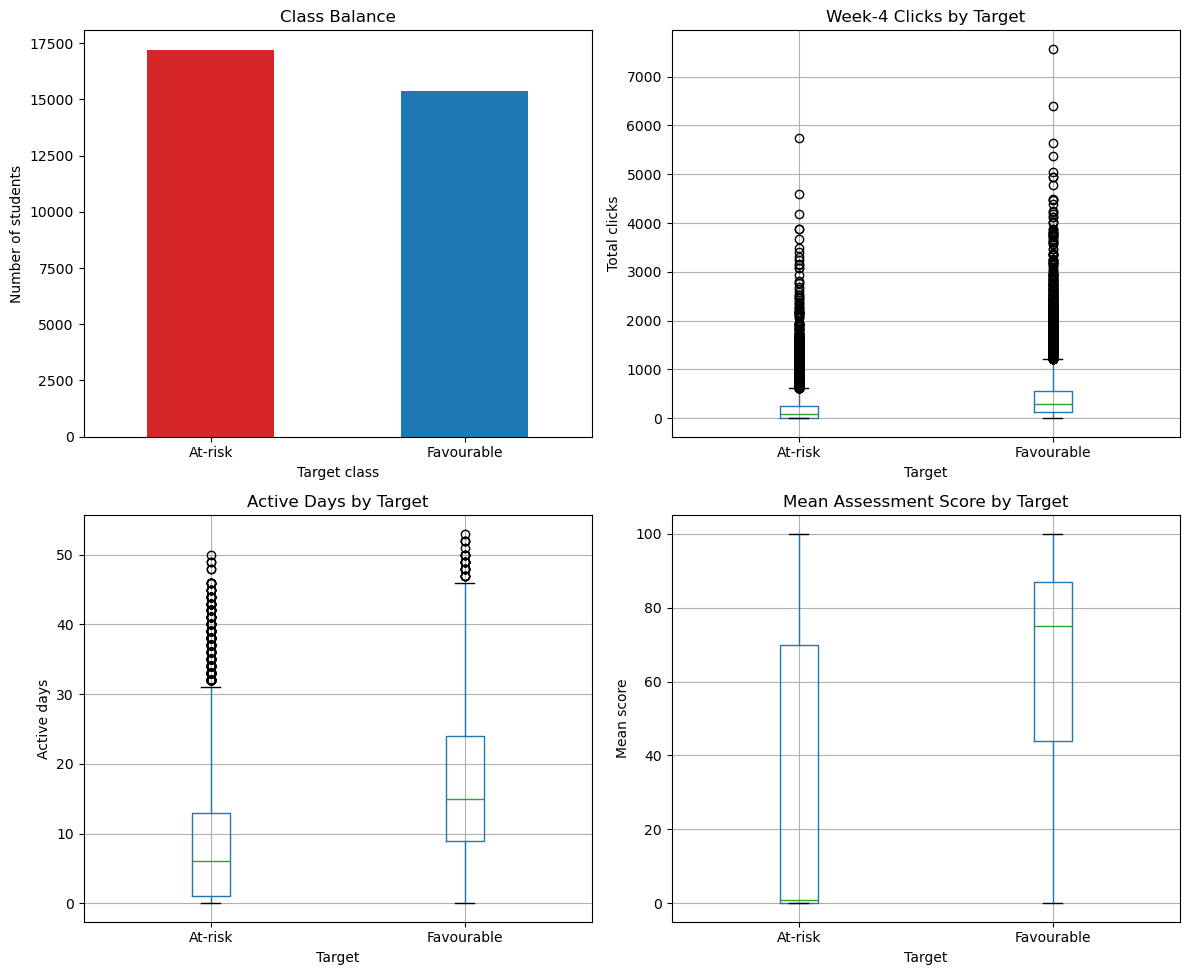

In [176]:
import matplotlib.pyplot as plt

required_objects = ["df"]
missing_objects = [name for name in required_objects if name not in globals()]

required_columns = ["target", "total_clicks_w4", "active_days_w4", "mean_score_w4"]

if missing_objects:
    print(
        "Section 16 EDA figures require the engineered dataframe from Section 6. "
        "Run Sections 2 to 6 first, then rerun this cell."
    )
else:
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        print(f"The dataframe `df` is missing expected columns: {', '.join(missing_columns)}")
    else:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))

        df["target"].value_counts().sort_index().plot(
            kind="bar",
            ax=axes[0, 0],
            color=["tab:red", "tab:blue"]
        )
        axes[0, 0].set_title("Class Balance")
        axes[0, 0].set_xlabel("Target class")
        axes[0, 0].set_ylabel("Number of students")
        axes[0, 0].set_xticklabels(["At-risk", "Favourable"], rotation=0)

        df.boxplot(column="total_clicks_w4", by="target", ax=axes[0, 1])
        axes[0, 1].set_title("Week-4 Clicks by Target")
        axes[0, 1].set_xlabel("Target")
        axes[0, 1].set_ylabel("Total clicks")
        axes[0, 1].set_xticklabels(["At-risk", "Favourable"], rotation=0)

        df.boxplot(column="active_days_w4", by="target", ax=axes[1, 0])
        axes[1, 0].set_title("Active Days by Target")
        axes[1, 0].set_xlabel("Target")
        axes[1, 0].set_ylabel("Active days")
        axes[1, 0].set_xticklabels(["At-risk", "Favourable"], rotation=0)

        df.boxplot(column="mean_score_w4", by="target", ax=axes[1, 1])
        axes[1, 1].set_title("Mean Assessment Score by Target")
        axes[1, 1].set_xlabel("Target")
        axes[1, 1].set_ylabel("Mean score")
        axes[1, 1].set_xticklabels(["At-risk", "Favourable"], rotation=0)

        fig.suptitle("")
        plt.tight_layout()
        plt.savefig("eda_overview.png", dpi=300, bbox_inches="tight")
        plt.show()


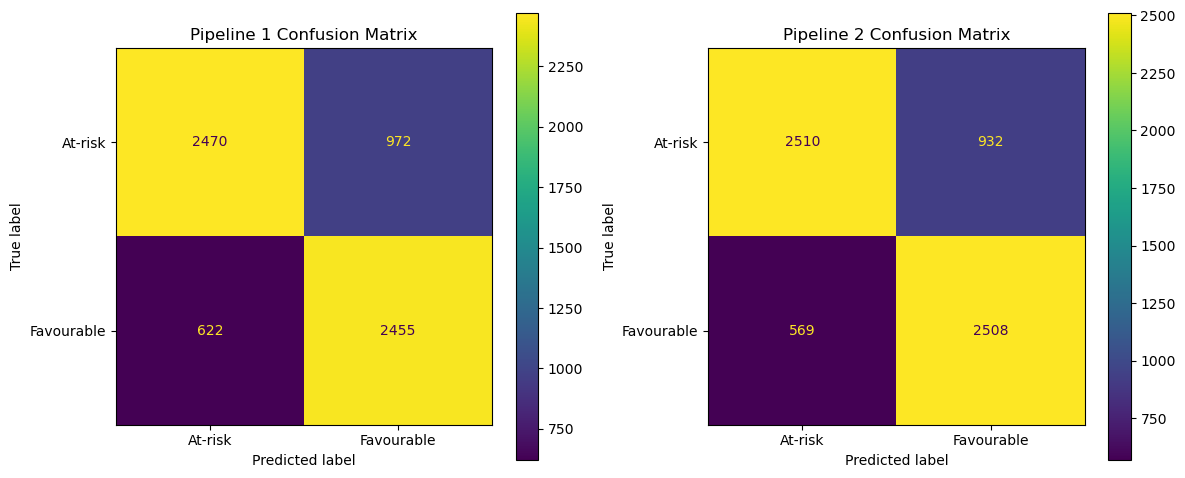

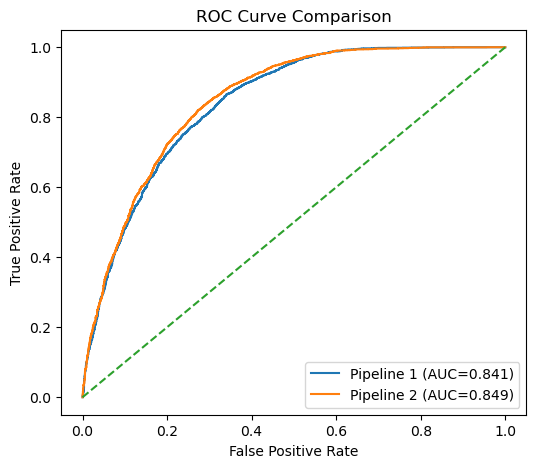

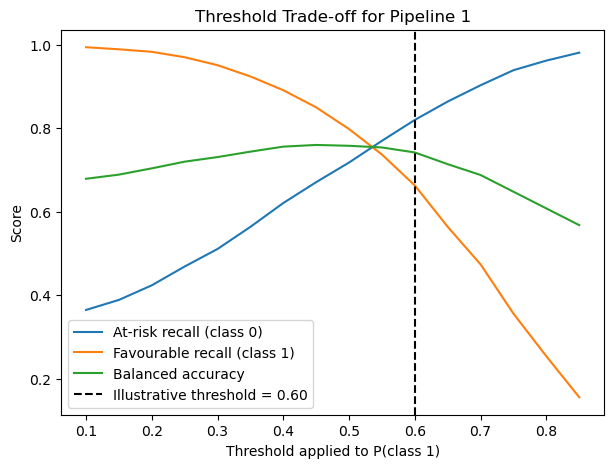

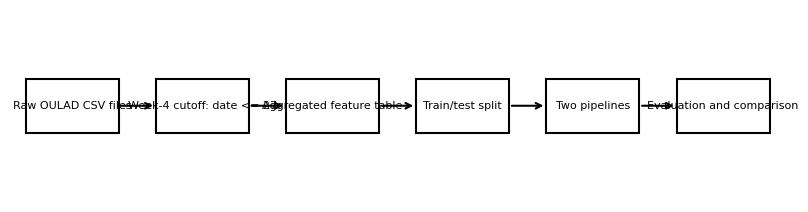

In [177]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

required_objects = [
    "y_test", "y_pred_p1", "y_pred_p2", "y_proba_p1", "y_proba_p2", "auc_p1", "auc_p2"
]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    print(
        "Section 16 performance figures require the evaluated outputs from Sections 9 and 11. "
        "Run the notebook through Section 11 first, then rerun this cell. "
        f"Missing: {', '.join(missing_objects)}"
    )
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_p1,
        display_labels=["At-risk", "Favourable"],
        ax=axes[0]
    )
    axes[0].set_title("Pipeline 1 Confusion Matrix")

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_p2,
        display_labels=["At-risk", "Favourable"],
        ax=axes[1]
    )
    axes[1].set_title("Pipeline 2 Confusion Matrix")

    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=300, bbox_inches="tight")
    plt.show()

    fpr1, tpr1, _ = roc_curve(y_test, y_proba_p1)
    fpr2, tpr2, _ = roc_curve(y_test, y_proba_p2)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr1, tpr1, label=f"Pipeline 1 (AUC={auc_p1:.3f})")
    plt.plot(fpr2, tpr2, label=f"Pipeline 2 (AUC={auc_p2:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    if "threshold_results" in globals() and not threshold_results.empty:
        plt.figure(figsize=(7, 5))
        plt.plot(threshold_results["threshold_for_class_1"], threshold_results["at_risk_recall_0"], label="At-risk recall (class 0)")
        plt.plot(threshold_results["threshold_for_class_1"], threshold_results["favourable_recall_1"], label="Favourable recall (class 1)")
        plt.plot(threshold_results["threshold_for_class_1"], threshold_results["balanced_accuracy"], label="Balanced accuracy")
        plt.axvline(0.60, linestyle="--", color="black", label="Illustrative threshold = 0.60")
        plt.xlabel("Threshold applied to P(class 1)")
        plt.ylabel("Score")
        plt.title("Threshold Trade-off for Pipeline 1")
        plt.legend()
        plt.savefig("threshold_sweep.png", dpi=300, bbox_inches="tight")
        plt.show()
    else:
        print("Threshold sweep figure skipped because `threshold_results` is not available yet.")

    steps = [
        "Raw OULAD CSV files",
        "Week-4 cutoff: date <= 27",
        "Aggregated feature table",
        "Train/test split",
        "Two pipelines",
        "Evaluation and comparison",
    ]

    fig, ax = plt.subplots(figsize=(10, 2.5))
    ax.axis("off")
    x_positions = np.linspace(0.08, 0.92, len(steps))
    y_pos = 0.5
    box_width = 0.12
    box_height = 0.28

    for x, text in zip(x_positions, steps):
        rect = plt.Rectangle(
            (x - box_width / 2, y_pos - box_height / 2),
            box_width,
            box_height,
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(rect)
        ax.text(x, y_pos, text, ha="center", va="center", fontsize=8)

    for i in range(len(x_positions) - 1):
        ax.annotate(
            "",
            xy=(x_positions[i + 1] - box_width / 2, y_pos),
            xytext=(x_positions[i] + box_width / 2, y_pos),
            arrowprops=dict(arrowstyle="->", linewidth=1.5)
        )

    plt.savefig("pipeline_diagram.png", dpi=300, bbox_inches="tight")
    plt.show()


Pipeline 1 log loss: 0.4784
Pipeline 2 log loss: 0.4692


,feature,importance
0,num__mean_score_w4,0.094186
1,cat__code_module,0.059273
2,num__active_days_w4,0.037000
3,num__page,0.015248
4,cat__highest_education,0.013407
5,num__assessments_done_w4,0.009204
6,num__oucontent,0.006596
7,cat__imd_band,0.006351
8,num__total_clicks_w4,0.005890
9,num__num_of_prev_attempts,0.004786


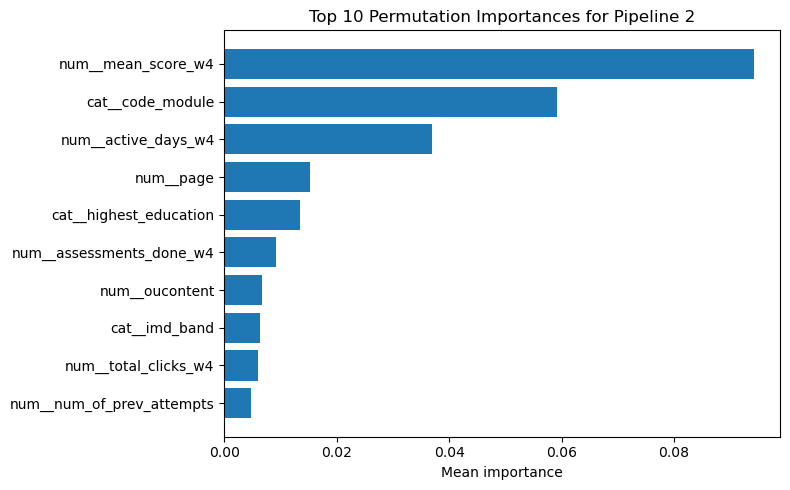

In [178]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import log_loss
from sklearn.inspection import permutation_importance

required_objects = ["pipeline_2", "X_test", "y_test", "y_proba_p1", "y_proba_p2"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    print(
        "Section 16 feature importance requires the trained advanced pipeline and test data. "
        "Run the notebook through Section 11 first, then rerun this cell. "
        f"Missing: {', '.join(missing_objects)}"
    )
else:
    print("Pipeline 1 log loss:", round(log_loss(y_test, y_proba_p1), 4))
    print("Pipeline 2 log loss:", round(log_loss(y_test, y_proba_p2), 4))

    perm_importance = permutation_importance(
        pipeline_2,
        X_test,
        y_test,
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    feature_names = pipeline_2.named_steps["preprocessor"].get_feature_names_out()

    feat_imp = (
        pd.DataFrame(
            {
                "feature": feature_names,
                "importance": perm_importance.importances_mean,
            }
        )
        .sort_values(by="importance", ascending=False)
        .reset_index(drop=True)
    )

    display(feat_imp.head(10))

    plt.figure(figsize=(8, 5))
    top10 = feat_imp.head(10).sort_values("importance", ascending=True)
    plt.barh(top10["feature"], top10["importance"])
    plt.title("Top 10 Permutation Importances for Pipeline 2")
    plt.xlabel("Mean importance")
    plt.tight_layout()
    plt.savefig("feature_importance_p2.png", dpi=300, bbox_inches="tight")
    plt.show()


## 17. Brief Compliance Check

The checklist below translates the major notebook-facing requirements from the brief into explicit evidence inside this notebook.


In [179]:
import pandas as pd
from IPython.display import display

compliance_check = pd.DataFrame(
    [
        {
            "Brief requirement": "Build and compare two ML pipelines",
            "Status": "Met",
            "Evidence in notebook": "Sections 8, 11, and 12 implement and compare two distinct pipelines.",
        },
        {
            "Brief requirement": "Use only data available up to week 4",
            "Status": "Met",
            "Evidence in notebook": "Section 5 filters VLE and assessment records to date <= 27.",
        },
        {
            "Brief requirement": "Engineer a manageable feature table instead of modeling the raw click table",
            "Status": "Met",
            "Evidence in notebook": "Section 6 aggregates engagement and assessment data into one row per student-course.",
        },
        {
            "Brief requirement": "Use OULAD core files and optional supporting files appropriately",
            "Status": "Met",
            "Evidence in notebook": "The notebook uses studentInfo, studentVle, vle, assessments, and studentAssessment.",
        },
        {
            "Brief requirement": "Provide a feature table and example",
            "Status": "Met",
            "Evidence in notebook": "Section 14 documents the engineered features and shows example rows from the modeling table.",
        },
        {
            "Brief requirement": "Provide a pipeline comparison table",
            "Status": "Met",
            "Evidence in notebook": "Section 15 summarizes the preprocessing, estimator, and motivation for each pipeline.",
        },
        {
            "Brief requirement": "Report model performance for an early at-risk prediction task",
            "Status": "Met",
            "Evidence in notebook": "Sections 9, 10, 12, and 13 report classification metrics, AUC, threshold trade-offs, and conclusions.",
        },
    ]
)

display(compliance_check)


,Brief requirement,Status,Evidence in notebook
0,Build and compare two ML pipelines,Met,"Sections 8, 11, and 12 implement and compare t..."
1,Use only data available up to week 4,Met,Section 5 filters VLE and assessment records t...
2,Engineer a manageable feature table instead of...,Met,Section 6 aggregates engagement and assessment...
3,Use OULAD core files and optional supporting f...,Met,"The notebook uses studentInfo, studentVle, vle..."
4,Provide a feature table and example,Met,Section 14 documents the engineered features a...
5,Provide a pipeline comparison table,Met,"Section 15 summarizes the preprocessing, estim..."
6,Report model performance for an early at-risk ...,Met,"Sections 9, 10, 12, and 13 report classificati..."
